In [1]:
import pandas as pd

# Load datasets
movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')

# Show data
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
movies.info()
ratings.info()

print(movies.shape)
print(ratings.shape)

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
(9742, 3)
(100836, 4)


In [3]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
movies.head(2)

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy


In [4]:
movies['tags'] = movies['genres']
movies[['title', 'tags']].head()

,title,tags
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,Jumanji (1995),Adventure Children Fantasy
2,Grumpier Old Men (1995),Comedy Romance
3,Waiting to Exhale (1995),Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy


In [5]:
movies.head(3)

,movieId,title,genres,tags
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance,Comedy Romance


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 5000, stop_words = 'english')
vectors = cv.fit_transform(movies['tags']).toarray()

In [7]:
print(type(vectors))
print(vectors.shape)

<class 'numpy.ndarray'>
(9742, 23)


In [8]:
sparse_matrix = cv.fit_transform(movies['tags'])
print(type(sparse_matrix))
print(sparse_matrix.shape)
print(sparse_matrix.nnz)
print(sparse_matrix[0])

<class 'scipy.sparse._csr.csr_matrix'>
(9742, 23)
23185
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (1, 23)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 8)	1


In [9]:
print(sparse_matrix[:5].toarray())
print(cv.get_feature_names_out()[:20])

[[0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'genres' 'horror' 'imax'
 'listed' 'musical' 'mystery' 'noir' 'romance' 'sci']


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vectors)
print(similarity.shape)

(9742, 9742)


In [11]:
# First 5x5 rows and columns dekho
print(similarity[:5, :5])

[[1.         0.77459667 0.31622777 0.25819889 0.4472136 ]
 [0.77459667 1.         0.         0.         0.        ]
 [0.31622777 0.         1.         0.81649658 0.70710678]
 [0.25819889 0.         0.81649658 1.         0.57735027]
 [0.4472136  0.         0.70710678 0.57735027 1.        ]]


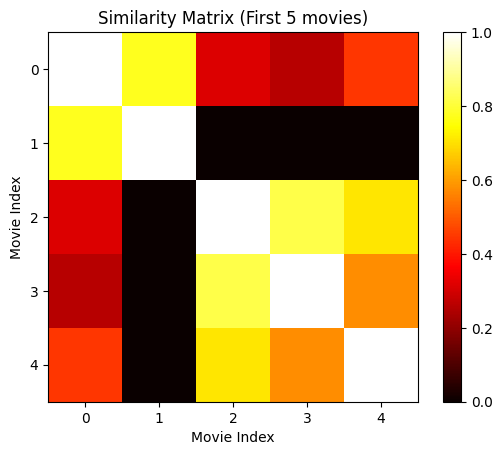

In [12]:
import matplotlib.pyplot as plt

plt.imshow(similarity[:5, :5], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Similarity Matrix (First 5 movies)')
plt.xlabel('Movie Index')
plt.ylabel('Movie Index')
plt.show()

Similarity Matrix ka matlab
Agar similarity matrix dekho to:

           Movie1  Movie2  Movie3  Movie4
Movie1      1.0    0.45    0.12    0.78
Movie2      0.45   1.0     0.89    0.23
Movie3      0.12   0.89    1.0     0.34
Movie4      0.78   0.23    0.34    1.0

Diagonal (1.0): movie apne aap se 100% match
0.45: Movie1 aur Movie2 mein 45% similarity hai
0.89: Movie2 aur Movie3 mein 89% similarity hai (bahut similar!)

In [13]:
def recommend(movie):
    movie_index = movies[movies['title'] == movie].index[0]
    
    distances = similarity[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    for i in movies_list:
        print(movies.iloc[i[0]].title)

In [14]:
recommend("Toy Story (1995)")

Antz (1998)
Toy Story 2 (1999)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Monsters, Inc. (2001)


In [15]:
recommend("Father of the Bride Part II (1995)")

Four Rooms (1995)
Ace Ventura: When Nature Calls (1995)
Bio-Dome (1996)
Friday (1995)
Black Sheep (1996)


In [16]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres,tags
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance,Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller,Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller,Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller,Crime Mystery Thriller


In [17]:
movie_ratings.groupby('title').count()['rating'].sort_values(ascending=False).head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

In [18]:
pt = movie_ratings.pivot_table(index='title', columns='userId', values='rating')
pt.fillna(0, inplace=True)

pt.head(20)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Salem's Lot (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Tis the Season for Love (2015),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"'burbs, The (1989)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'night Mother (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
(500) Days of Summer (2009),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5


In [19]:
print(pt.loc['Toy Story (1995)'].head(20))

userId
1     4.0
2     0.0
3     0.0
4     0.0
5     4.0
6     0.0
7     4.5
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    2.5
16    0.0
17    4.5
18    3.5
19    4.0
20    0.0
Name: Toy Story (1995), dtype: float64


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(pt)

In [21]:
import pandas as pd

similarity_df = pd.DataFrame(similarity_scores, index=pt.index, columns=pt.index)
similarity_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [22]:
def recommend_rating(movie):
    index = pt.index.get_loc(movie)
    distances = similarity_scores[index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    for i in movies_list:
        print(pt.index[i[0]])

In [23]:
recommend_rating("Toy Story (1995)")

Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


In [24]:
import numpy as np
R = pt.values
num_users, num_movies = R.shape
k = 20  # latent features

In [25]:
P = np.random.rand(num_users, k)
Q = np.random.rand(num_movies, k)

In [26]:
alpha = 0.002  # learning rate
beta = 0.02    # regularization

for step in range(10):
    for i in range(num_users):
        for j in range(num_movies):
            if R[i][j] > 0:
                eij = R[i][j] - np.dot(P[i, :], Q[j, :].T)

                for k_ in range(k):
                    P[i][k_] += alpha * (2 * eij * Q[j][k_] - beta * P[i][k_])
                    Q[j][k_] += alpha * (2 * eij * P[i][k_] - beta * Q[j][k_])

In [27]:
R_pred = np.dot(P, Q.T)

In [28]:
def recommend_mf(user_index, n=5):
    user_ratings = R_pred[user_index]
    
    top_movies = np.argsort(user_ratings)[::-1][:n]
    
    for i in top_movies:
        print(pt.index[i])

In [29]:
recommend_mf(0)

13 Ghosts (1960)
16 Blocks (2006)
Agent Cody Banks (2003)
Alien³ (a.k.a. Alien 3) (1992)
Advise and Consent (1962)


In [30]:
import requests

url = "http://www.omdbapi.com/?t=Titanic&apikey=e6946520"
print(requests.get(url).json())

{'Title': 'Titanic', 'Year': '1997', 'Rated': 'PG-13', 'Released': '19 Dec 1997', 'Runtime': '194 min', 'Genre': 'Drama, Romance', 'Director': 'James Cameron', 'Writer': 'James Cameron', 'Actors': 'Leonardo DiCaprio, Kate Winslet, Billy Zane', 'Plot': 'A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.', 'Language': 'English, Swedish, Italian, French', 'Country': 'United States, Mexico', 'Awards': 'Won 11 Oscars. 126 wins & 84 nominations total', 'Poster': 'https://m.media-amazon.com/images/M/MV5BYzYyN2FiZmUtYWYzMy00MzViLWJkZTMtOGY1ZjgzNWMwN2YxXkEyXkFqcGc@._V1_QL75_UX380_CR0,2,380,562_.jpg', 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '8.0/10'}, {'Source': 'Rotten Tomatoes', 'Value': '88%'}, {'Source': 'Metacritic', 'Value': '75/100'}], 'Metascore': '75', 'imdbRating': '8.0', 'imdbVotes': '1,389,357', 'imdbID': 'tt0120338', 'Type': 'movie', 'DVD': 'N/A', 'BoxOffice': '$674,354,882', 'Production': 'N/A